# Department Co-purchases with Produce

The merchandising analytics team wants to understand how frequently different product departments are purchased together with Produce.

## Load and prepare the data

Load the prior purchase history and map each purchased product to its department.

In [1]:
import pandas as pd


DATA_DIR = "../../data/shop"

order_products = pd.read_csv(
    f"{DATA_DIR}/order_products__prior.csv",
    usecols=["order_id", "product_id"],
)

products = pd.read_csv(
    f"{DATA_DIR}/products.csv",
    usecols=["product_id", "department_id"],
)

departments = pd.read_csv(
    f"{DATA_DIR}/departments.csv",
)

order_products = order_products.merge(
    products,
    on="product_id",
    how="left",
)

## Identify Produce orders

Identify all orders containing at least one Produce product. These orders define the purchase history used for the co-purchase comparison.

In [2]:
produce_id = departments.loc[
    departments["department"].eq("produce"),
    "department_id",
].iloc[0]

produce_orders = order_products.loc[
    order_products["department_id"].eq(produce_id),
    "order_id",
].unique()

## Calculate department co-purchase counts

Within Produce orders, count purchases from the other departments and rank them by co-purchase frequency.

In [3]:
produce_items = order_products[
    order_products["order_id"].isin(produce_orders)
    & order_products["department_id"].ne(produce_id)
]

copurchase_counts = (
    produce_items["department_id"]
    .value_counts()
    .rename_axis("department_id")
    .reset_index(name="copurchase_count")
    .merge(
        departments,
        on="department_id",
        how="left",
    )
    [["department", "copurchase_count"]]
)

## Rank departments

Report the departments with the highest co-purchase counts in Produce orders.

In [4]:
print("Top departments purchased with Produce:")

print(
    copurchase_counts
    .head(15)
    .to_string(index=False)
)

Top departments purchased with Produce:
     department  copurchase_count
     dairy eggs           4604171
         snacks           2270136
      beverages           1956409
         frozen           1822481
         pantry           1574727
         bakery            990718
   canned goods            948397
           deli            911674
dry goods pasta            757995
   meat seafood            625998
      breakfast            569331
      household            499415
         babies            359051
  personal care            307563
  international            234907


## Visualize department co-purchases

Compare the leading departments by co-purchase count. The chart also reports the number of Produce orders and purchase records represented in the analysis.

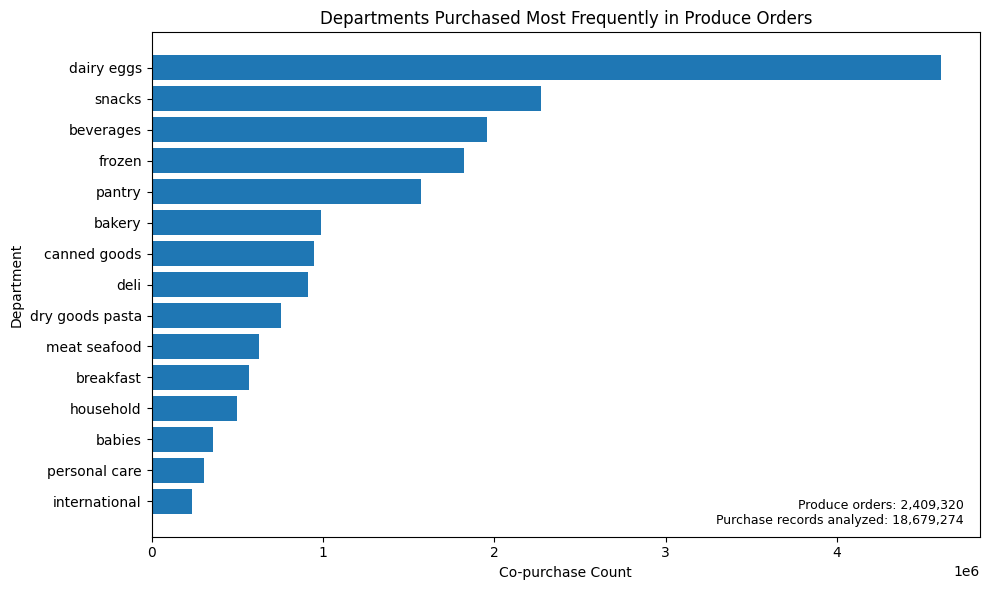

In [5]:
import matplotlib.pyplot as plt

top_departments = (
    copurchase_counts
    .head(15)
    .sort_values(
        "copurchase_count",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    top_departments["department"],
    top_departments["copurchase_count"],
)

ax.set_title(
    "Departments Purchased Most Frequently "
    "in Produce Orders"
)

ax.set_xlabel(
    "Co-purchase Count"
)

ax.set_ylabel(
    "Department"
)

ax.text(
    0.98,
    0.02,
    (
        f"Produce orders: {len(produce_orders):,}\n"
        f"Purchase records analyzed: {len(produce_items):,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
)

plt.tight_layout()
plt.show()

## Conclusion

The chart shows which departments account for the largest numbers of purchases within orders containing Produce.

Departments with higher counts are more frequently represented among purchased items in Produce orders and may be useful candidates for cross-merchandising or joint promotions with Produce.